In [1]:
import os
import io
import pandas as pd
import numpy as np
from urllib import request
from tqdm import trange
from pathlib import Path
import matplotlib.pyplot as plt
from urllib import request
from PIL import Image
from typing import Optional, List, Tuple, Any, Dict

from torch.utils.data import Dataset
from torchvision import transforms
from inspect import isclass
import random

from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import torch, torch.nn as nn, random
from collections import Counter


from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score
)

## Dataset Folder Path

In [2]:
############################### Define dataset paths (Change the Path Accordingly)
BASE_DATA_DIR = Path("/Users/abdullah/Desktop/Courses/Pattern/project_dataset/fakeddit_data/multimodal_only_samples")
BASE_DATA_DIR.mkdir(parents=True, exist_ok=True)

## Download Original Dataset (.TSV Files)

In [3]:
#!pip install gdown

In [4]:
# gdrive_folder_link = "https://drive.google.com/drive/folders/1wlXco9RhOnChKAKX9-gRwXhsg9s3hnWs?usp=sharing"
# os.system(f"gdown --folder {gdrive_folder_link} -O {BASE_DATA_DIR}")

## Loading the Dataset

In [5]:
############################ Function to load dataset
def load_dataset(filename: str, sep="\t") -> pd.DataFrame:
    file_path = BASE_DATA_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found. Please check dataset setup.")
    return pd.read_csv(file_path, sep=sep)

In [6]:
############################### Load train, validation, and test datasets
train_df = load_dataset("multimodal_train.tsv")
val_df   = load_dataset("multimodal_validate.tsv")
test_df  = load_dataset("multimodal_test_public.tsv")

In [7]:
print("Train dataset shape      :", train_df.shape)
print("Validation dataset shape :", val_df.shape)
print("Test dataset shape       :", test_df.shape)

Train dataset shape      : (564000, 16)
Validation dataset shape : (59342, 16)
Test dataset shape       : (59319, 16)


In [8]:
print("\nColumn names and types in train dataset:")
for col in train_df.columns:
    print(f"- {col} ({train_df[col].dtype})")


Column names and types in train dataset:
- author (object)
- clean_title (object)
- created_utc (float64)
- domain (object)
- hasImage (bool)
- id (object)
- image_url (object)
- linked_submission_id (object)
- num_comments (float64)
- score (int64)
- subreddit (object)
- title (object)
- upvote_ratio (float64)
- 2_way_label (int64)
- 3_way_label (int64)
- 6_way_label (int64)


## Download the Images

In [9]:
def create_subcsv_and_download(df, base_dir, csv_name="train_subset.csv", img_folder="train_images", limit=10):
    # clean
    df = df.replace(np.nan, '', regex=True)
    df.fillna('', inplace=True)

    ############################### paths
    img_dir = os.path.join(base_dir, img_folder)
    os.makedirs(img_dir, exist_ok=True)

    picked = []
    count = 0

    ############################### progress bar setup
    if limit == -1:
        iterator = tqdm(df.iterrows(), total=len(df), desc="Downloading images", unit="row")
    else:
        iterator = df.iterrows()
        pbar = trange(limit, desc="Downloading images", unit="img")

    for _, row in iterator:
        if limit != -1 and count >= limit:
            break

        if row["hasImage"] == True and row["image_url"] not in ["", "nan"]:
            url = row["image_url"]
            final_path = os.path.join(img_dir, f"{row['id']}.jpg")
            tmp_path = final_path + ".tmp"

            try:
                data = request.urlopen(url, timeout=12).read()
                if not data or len(data) < 100:
                    continue

                with open(tmp_path, "wb") as f:
                    f.write(data)
                os.replace(tmp_path, final_path)

                picked.append(row)
                if limit != -1:
                    count += 1
                    pbar.update(1)

            except:
                if os.path.exists(tmp_path):
                    os.remove(tmp_path)
                continue

    if limit != -1:
        pbar.close()

    ############################### save CSV of successfully downloaded rows
    out_csv = os.path.join(base_dir, csv_name)
    pd.DataFrame(picked).to_csv(out_csv, index=False)
    print(f"\nCreated {out_csv} with {len(picked)} rows")
    print(f"Images saved in {img_dir}")

In [10]:
# ############################### Train Sub dataset
# create_subcsv_and_download(
#     df=train_df,
#     base_dir=str(BASE_DATA_DIR),
#     csv_name="train_subset.csv",
#     img_folder="train_images",
#     limit=20000
# )

# ############################### Valid Sub dataset
# create_subcsv_and_download(
#     df=val_df,
#     base_dir=str(BASE_DATA_DIR),
#     csv_name="valid_subset.csv",
#     img_folder="valid_images",
#     limit=2000
# )

# ############################### Test Sub dataset
# create_subcsv_and_download(
#     df=test_df,
#     base_dir=str(BASE_DATA_DIR),
#     csv_name="test_subset.csv",
#     img_folder="test_images",
#     limit=2000
# )

## Printing a few Examples

In [11]:
TRAIN_SUBCSV   = "train_subset.csv"
TRAIN_IMG_DIR  = BASE_DATA_DIR / "train_images"
train_sub_df = pd.read_csv(BASE_DATA_DIR / TRAIN_SUBCSV)
print(f"Loaded {TRAIN_SUBCSV} with {len(train_sub_df):,} rows")


VALID_SUBCSV   = "valid_subset.csv"
VALID_IMG_DIR  = BASE_DATA_DIR / "valid_images"
valid_sub_df = pd.read_csv(BASE_DATA_DIR / VALID_SUBCSV)
print(f"Loaded {VALID_SUBCSV} with {len(valid_sub_df):,} rows")


TEST_SUBCSV   = "test_subset.csv"
TEST_IMG_DIR  = BASE_DATA_DIR / "test_images"
test_sub_df = pd.read_csv(BASE_DATA_DIR / TEST_SUBCSV)
print(f"Loaded {TEST_SUBCSV} with {len(test_sub_df):,} rows")

Loaded train_subset.csv with 20,000 rows
Loaded valid_subset.csv with 2,000 rows
Loaded test_subset.csv with 2,000 rows


In [12]:
############################################  Helper: resolve image filepath from ID
def find_image_path(sample_id, IMG_DIR):
    sid = str(sample_id)
    candidates = [IMG_DIR / f"{sid}.jpg",
                  IMG_DIR / f"{sid}.jpeg",
                  IMG_DIR / f"{sid}.png"]
    for p in candidates:
        if p.exists():
            return p
    return None

In [13]:
############################################  Print a few samples (ID + labels)
def print_samples(df: pd.DataFrame, k: int, IMG_DIR):
    cols_needed = ["id", "2_way_label", "3_way_label", "6_way_label"]
    missing = [c for c in cols_needed if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in CSV: {missing}")

    print("\n############################################  Sample rows (ID + labels)")
    shown = 0
    for _, row in df.iterrows():
        img_path = find_image_path(row["id"], IMG_DIR)
        if img_path is None:
            continue
        print(f"- id: {row['id']} | 2_way: {row['2_way_label']} | 3_way: {row['3_way_label']} | 6_way: {row['6_way_label']}")
        shown += 1
        if shown >= k:
            break
    if shown == 0:
        print("No matching images found for the first rows. Check image folder/IDs.")

In [14]:
############################################  Display a few images with labels
def show_images(df: pd.DataFrame, IMG_DIR, k: int = 2):
    shown = 0
    for _, row in df.iterrows():
        img_path = find_image_path(row["id"], IMG_DIR)
        if img_path is None:
            continue

        # Load and show image
        img = Image.open(img_path)
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"id: {row['id']}\n"
            f"2-way: {row['2_way_label']} | 3-way: {row['3_way_label']} | 6-way: {row['6_way_label']}"
        )
        plt.show()

        shown += 1
        if shown >= k:
            break
    if shown == 0:
        print("No images displayed (files not found). Verify filenames/extension.")


############################################  Sample rows (ID + labels)
- id: awxhir | 2_way: 1 | 3_way: 0 | 6_way: 0


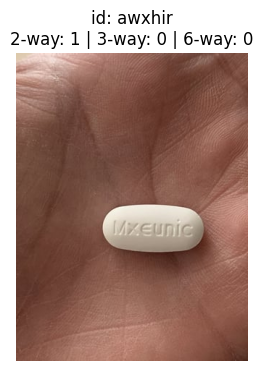


############################################  Sample rows (ID + labels)
- id: cypw96 | 2_way: 1 | 3_way: 0 | 6_way: 0


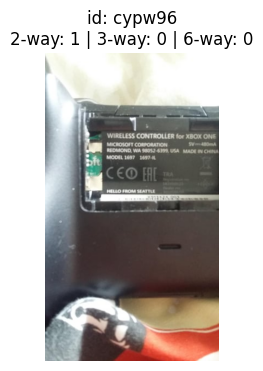


############################################  Sample rows (ID + labels)
- id: c0gl7r | 2_way: 1 | 3_way: 0 | 6_way: 0


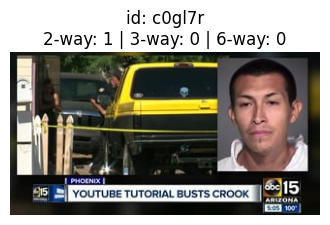

In [15]:
############################################ print & visualize a couple of examples

# Train
print_samples(train_sub_df, k=1, IMG_DIR=TRAIN_IMG_DIR)
show_images(train_sub_df, IMG_DIR=TRAIN_IMG_DIR, k=1)

# Valid
print_samples(valid_sub_df, k=1, IMG_DIR=VALID_IMG_DIR)
show_images(valid_sub_df, IMG_DIR=VALID_IMG_DIR, k=1)

# Test
print_samples(test_sub_df, k=1, IMG_DIR=TEST_IMG_DIR)
show_images(test_sub_df, IMG_DIR=TEST_IMG_DIR, k=1)

## Removing the Data Point / Images that are Unabailavble (but we got an Image)

In [16]:
############################################  Function: clean dataset based on image dimensions Based on Img Size
def clean_dataset_by_image_size(df, img_dir, min_size, out_csv_name, show_example):
    valid_ids = []
    removed_ids = []

    ####################################### Check all images
    for _, row in df.iterrows():
        img_path = img_dir / f"{row['id']}.jpg"
        if not img_path.exists():
            continue

        try:
            with Image.open(img_path) as img:
                w, h = img.size
                if w >= min_size[0] and h >= min_size[1]:
                    valid_ids.append(row['id'])
                else:
                    removed_ids.append((row['id'], w, h))
        except Exception:
            removed_ids.append((row['id'], -1, -1))

    ####################################### Show one example valid + one example removed
    if show_example:
        print("\n############################################  Example Removed Image")
        for rid, w, h in removed_ids:
            img_path = img_dir / f"{rid}.jpg"
            if img_path.exists():
                row = df[df['id'] == rid].iloc[0]
                print(f"ID: {rid} | size: {w}x{h}")
                print(f"Labels: 2-way={row['2_way_label']}, 3-way={row['3_way_label']}, 6-way={row['6_way_label']}")
                display(Image.open(img_path))
                break

    ####################################### Filter dataframe
    clean_df = df[df['id'].isin(valid_ids)].reset_index(drop=True)

    ####################################### Save cleaned CSV
    out_path = BASE_DATA_DIR / out_csv_name
    clean_df.to_csv(out_path, index=False)

    print("\n############################################  Cleaning Summary")
    print(f"Original rows: {len(df)}")
    print(f"Kept rows    : {len(clean_df)}")
    print(f"Removed rows : {len(removed_ids)}")
    if removed_ids:
        print("Example removed IDs and sizes:", removed_ids[:5])

    return clean_df


############################################  Example Removed Image
ID: c9ede6 | size: 108x54
Labels: 2-way=0, 3-way=2, 6-way=3


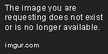


############################################  Cleaning Summary
Original rows: 20000
Kept rows    : 19815
Removed rows : 185
Example removed IDs and sizes: [('c9ede6', 108, 54), ('bxpm9p', 108, 54), ('5ghanc', 108, 43), ('36n7x7', 108, 54), ('2yo9ex', 108, 54)]


In [17]:
clean_train_df = clean_dataset_by_image_size(
    train_sub_df,
    TRAIN_IMG_DIR,
    min_size=(100, 60),
    out_csv_name="train_subset_clean.csv",
    show_example=True
)

In [18]:
clean_valid_df = clean_dataset_by_image_size(
    valid_sub_df,
    VALID_IMG_DIR,
    min_size=(100, 60),
    out_csv_name="valid_subset_clean.csv",
    show_example=False
)


############################################  Cleaning Summary
Original rows: 2000
Kept rows    : 1993
Removed rows : 7
Example removed IDs and sizes: [('c9u6k4', 320, 45), ('ds4mu90', -1, -1), ('bxmnqs', 108, 35), ('ccekgkq', -1, -1), ('xa7t5', 108, 54)]


In [19]:
clean_test_df = clean_dataset_by_image_size(
    test_sub_df,
    TEST_IMG_DIR,
    min_size=(100, 60),
    out_csv_name="test_subset_clean.csv",
    show_example=False
)


############################################  Cleaning Summary
Original rows: 2000
Kept rows    : 1988
Removed rows : 12
Example removed IDs and sizes: [('47xzdt', 108, 54), ('1y9yab', 108, 54), ('2vyyqw', 108, 54), ('7gfgas', 108, 54), ('29k3ow', 108, 54)]


## Building the Image DataFrame / Dataset

In [20]:
############################################ Build image DataFrame (resolve paths & dimensions)
def build_image_df_with_dims(csv_path, img_dir, exts = (".jpg", ".jpeg", ".png"), required_cols: Optional[List[str]] = None, preview_rows: int = 5):
    if required_cols is None:
        required_cols = ["id", "2_way_label", "3_way_label", "6_way_label"]

    df = pd.read_csv(csv_path).copy()

    ############################ validate required columns
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required columns in {csv_path}: {missing}")

    ############################ resolve <id>.<ext> to an existing file
    def _resolve(sample_id):
        sid = str(sample_id)
        for ext in exts:
            p = Path(img_dir) / f"{sid}{ext}"
            if p.exists():
                return p
        return None

    df["img_path"] = df["id"].apply(_resolve)
    df = df.dropna(subset=["img_path"]).reset_index(drop=True)

    ############################ add width/height
    widths, heights = [], []
    for p in df["img_path"]:
        try:
            with Image.open(p) as im:
                w, h = im.size
        except Exception:
            w, h = -1, -1
        widths.append(w)
        heights.append(h)
    df["width"] = widths
    df["height"] = heights

    ############################ tidy order
    df["img_path"] = df["img_path"].astype(str)
    keep_cols = ["id", "2_way_label", "3_way_label", "6_way_label", "img_path", "width", "height"]
    df = df[keep_cols]

    ############################ summary + preview
    print("############################################  Image DF Summary")
    print(f"✅ Rows with existing images: {len(df):,}\n")

    print("############################################  Preview (top rows)")
    display(df.head(preview_rows))  # cleaner Jupyter table

    return df

In [21]:
############################################  Create image dataset (images + multi-labels + id + dims)
class FakedditImageDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
        self.transform = transforms.Compose([transforms.ToTensor()])  # no resizing

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["img_path"]).convert("RGB")
        img = self.transform(img)
        return {
            "image":   img,
            "id":      str(row["id"]),
            "y2":      int(row["2_way_label"]),
            "y3":      int(row["3_way_label"]),
            "y6":      int(row["6_way_label"]),
            "width":   int(row["width"]),
            "height":  int(row["height"]),
            "img_path": row["img_path"],
        }

def build_dataset_and_print_sample(df):
    ############################ build dataset
    ds = FakedditImageDataset(df)

    print("\n############################################  Dataset Summary")
    print(f"✅ Total items: {len(ds):,}\n")

    ############################ print one sample
    if len(ds) > 0:
        sample = ds[0]
        print("############################################  Sample Item")
        print(f"- ID: {sample['id']}")
        print(f"- Labels: 2-way={sample['y2']} | 3-way={sample['y3']} | 6-way={sample['y6']}")
        print(f"- Tensor shape: {tuple(sample['image'].shape)}  (C,H,W)")
        print(f"- Dimensions: {sample['width']} x {sample['height']} (WxH)")
        print(f"- Path: {sample['img_path']}")
    return ds

In [22]:
CLEAN_CSV     = f"{BASE_DATA_DIR}/train_subset_clean.csv"
TRAIN_IMG_DIR = f"{BASE_DATA_DIR}/train_images"

# Build DataFrame with resolved paths + dimensions
img_df_train = build_image_df_with_dims(CLEAN_CSV, TRAIN_IMG_DIR, preview_rows=5)
# Build Dataset and print one sample
dataset_train = build_dataset_and_print_sample(img_df_train)

############################################  Image DF Summary
✅ Rows with existing images: 19,815

############################################  Preview (top rows)


,id,2_way_label,3_way_label,6_way_label,img_path,width,height
0,awxhir,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,426
1,6f2cy5,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,179
2,4xypkv,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,240
3,2vkbtj,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,242
4,6d50rl,0,2,2,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,568



############################################  Dataset Summary
✅ Total items: 19,815

############################################  Sample Item
- ID: awxhir
- Labels: 2-way=1 | 3-way=0 | 6-way=0
- Tensor shape: (3, 426, 320)  (C,H,W)
- Dimensions: 320 x 426 (WxH)
- Path: /Users/abdullah/Desktop/Courses/Pattern/project_dataset/fakeddit_data/multimodal_only_samples/train_images/awxhir.jpg


In [23]:
CLEAN_CSV     = f"{BASE_DATA_DIR}/valid_subset_clean.csv"
VALID_IMG_DIR = f"{BASE_DATA_DIR}/valid_images"

img_df_valid = build_image_df_with_dims(CLEAN_CSV, VALID_IMG_DIR, preview_rows=5)
dataset_valid = build_dataset_and_print_sample(img_df_valid)

############################################  Image DF Summary
✅ Rows with existing images: 1,993

############################################  Preview (top rows)


,id,2_way_label,3_way_label,6_way_label,img_path,width,height
0,cypw96,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,568
1,d0bzlq,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,213
2,bq3yuk,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,426
3,8rsoq0,0,2,2,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,388
4,33sekv,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,426



############################################  Dataset Summary
✅ Total items: 1,993

############################################  Sample Item
- ID: cypw96
- Labels: 2-way=1 | 3-way=0 | 6-way=0
- Tensor shape: (3, 568, 320)  (C,H,W)
- Dimensions: 320 x 568 (WxH)
- Path: /Users/abdullah/Desktop/Courses/Pattern/project_dataset/fakeddit_data/multimodal_only_samples/valid_images/cypw96.jpg


In [24]:
CLEAN_CSV     = f"{BASE_DATA_DIR}/test_subset_clean.csv"
TEST_IMG_DIR = f"{BASE_DATA_DIR}/test_images"

img_df_test = build_image_df_with_dims(CLEAN_CSV, TEST_IMG_DIR, preview_rows=5)
dataset_test = build_dataset_and_print_sample(img_df_test)

############################################  Image DF Summary
✅ Rows with existing images: 1,988

############################################  Preview (top rows)


,id,2_way_label,3_way_label,6_way_label,img_path,width,height
0,c0gl7r,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,168
1,c0xdqy,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,167
2,7o9rmx,0,1,5,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,481
3,bdfxf1,0,2,2,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,467
4,26kwdf,1,0,0,/Users/abdullah/Desktop/Courses/Pattern/projec...,320,270



############################################  Dataset Summary
✅ Total items: 1,988

############################################  Sample Item
- ID: c0gl7r
- Labels: 2-way=1 | 3-way=0 | 6-way=0
- Tensor shape: (3, 168, 320)  (C,H,W)
- Dimensions: 320 x 168 (WxH)
- Path: /Users/abdullah/Desktop/Courses/Pattern/project_dataset/fakeddit_data/multimodal_only_samples/test_images/c0gl7r.jpg


## Data Pre-processing

### Fixed-size transform

In [25]:
############################################ set fixed-size transform (resize/crop → tensor)
def set_fixed_size_transform(dataset, size=(224, 224), crop_mode="center", show_example=True):
    ############################ build PIL-side steps
    H, W = size
    steps = []
    if crop_mode == "center":
        steps += [transforms.Resize(min(H, W)), transforms.CenterCrop((H, W))]
    elif crop_mode == "random":
        steps += [transforms.RandomResizedCrop((H, W), scale=(0.8, 1.0), ratio=(3/4, 4/3))]
    else:
        steps += [transforms.Resize((H, W))]

    ############################ full pipeline (PIL → Tensor)
    pipeline = steps + [transforms.ToTensor()]
    dataset.transform = transforms.Compose(pipeline)

    ############################ print summary
    print("############################################  Transform")
    for i, op in enumerate(dataset.transform.transforms):
        name = op.__class__.__name__ if not isclass(op) else op.__name__
        print(f"{i+1:>2}. {name}")

    ############################ show one example before/after
    if show_example and len(dataset) > 0:
        sample = dataset.df.iloc[8]
        img_path = sample["img_path"]

        # Original
        orig_img = Image.open(img_path).convert("RGB")

        # Transformed
        transformed = dataset.transform(orig_img)

        print("\n############################################  Example Image")
        print(f"ID: {sample['id']}, Labels: {sample['2_way_label']} / {sample['3_way_label']} / {sample['6_way_label']}")
        print(f"- Original size : {orig_img.size} (WxH)")
        print(f"- Transformed shape: {tuple(transformed.shape)} (C,H,W)")

        # Plot side by side
        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
        axs[0].imshow(orig_img)
        axs[0].set_title("Original")
        axs[0].axis("off")

        axs[1].imshow(transformed.permute(1, 2, 0))  # C,H,W → H,W,C
        axs[1].set_title("After Transform")
        axs[1].axis("off")

        plt.show()

    return dataset

############################################  Transform
 1. Resize
 2. CenterCrop
 3. ToTensor

############################################  Example Image
ID: 4zd1tb, Labels: 1 / 0 / 0
- Original size : (320, 167) (WxH)
- Transformed shape: (3, 224, 224) (C,H,W)


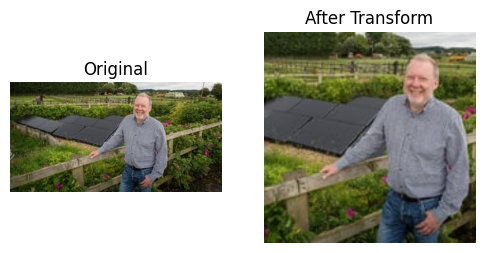

In [26]:
dataset_train = set_fixed_size_transform(dataset_train, size=(224, 224), crop_mode="center")

############################################  Transform
 1. Resize
 2. CenterCrop
 3. ToTensor

############################################  Example Image
ID: baoflq, Labels: 1 / 0 / 0
- Original size : (320, 426) (WxH)
- Transformed shape: (3, 224, 224) (C,H,W)


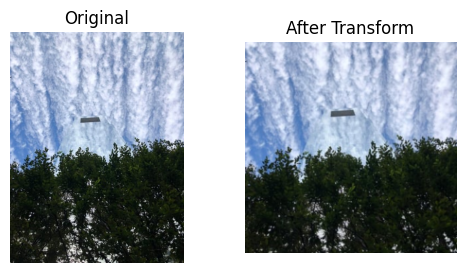

In [27]:
dataset_valid = set_fixed_size_transform(dataset_valid, size=(224, 224), crop_mode="center")

############################################  Transform
 1. Resize
 2. CenterCrop
 3. ToTensor

############################################  Example Image
ID: 7iqceh, Labels: 0 / 2 / 2
- Original size : (320, 426) (WxH)
- Transformed shape: (3, 224, 224) (C,H,W)


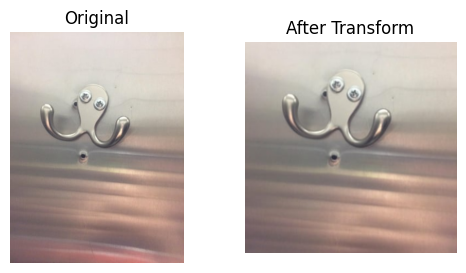

In [28]:
dataset_test = set_fixed_size_transform(dataset_test, size=(224, 224), crop_mode="center")

### Estimate mean/std

In [29]:
############################################ estimate mean/std without DataLoader
def estimate_mean_std_singlepass(dataset, max_samples=2000, seed=42, show_every=0):
    ############################ choose indices
    rnd = random.Random(seed)
    n = min(len(dataset), max_samples)
    indices = list(range(len(dataset)))
    rnd.shuffle(indices)
    indices = indices[:n]

    ############################ accumulate channel stats
    n_pixels = 0
    sum_c   = torch.zeros(3, dtype=torch.float64)
    sumsq_c = torch.zeros(3, dtype=torch.float64)

    for i, idx in enumerate(indices, 1):
        x = dataset[idx]["image"].to(dtype=torch.float64)   # [3,H,W] in [0,1]
        c, h, w = x.shape
        n_pixels += h * w
        x = x.reshape(c, -1)
        sum_c   += x.sum(dim=1)
        sumsq_c += (x ** 2).sum(dim=1)

        if show_every and (i % show_every == 0):
            print(f"… processed {i}/{n}")

    mean = (sum_c / n_pixels).to(dtype=torch.float32)
    var  = (sumsq_c / n_pixels - mean.double() ** 2).to(dtype=torch.float32)
    std  = torch.sqrt(var.clamp_min(1e-12))

    mean_list = mean.tolist()
    std_list  = std.tolist()

    ############################ report
    print("############################################  Estimated mean/std (from images)")
    print(f"Samples used : {n}")
    print(f"mean         : {[round(m, 4) for m in mean_list]}")
    print(f"std          : {[round(s, 4) for s in std_list]}")
    return mean_list, std_list

In [30]:
mean_train, std_train = estimate_mean_std_singlepass(dataset_train, max_samples=5000)
mean_valid, std_valid = estimate_mean_std_singlepass(dataset_valid, max_samples=1000)
mean_test, std_test = estimate_mean_std_singlepass(dataset_test, max_samples=1000)

/Users/abdullah/.pyenv/versions/3.8.18/lib/python3.8/site-packages/PIL/Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


############################################  Estimated mean/std (from images)
Samples used : 5000
mean         : [0.4813, 0.4442, 0.4125]
std          : [0.2896, 0.2783, 0.2828]
############################################  Estimated mean/std (from images)
Samples used : 1000
mean         : [0.4867, 0.4519, 0.4229]
std          : [0.2928, 0.2805, 0.2866]
############################################  Estimated mean/std (from images)
Samples used : 1000
mean         : [0.4853, 0.4526, 0.4271]
std          : [0.2883, 0.2775, 0.2833]


### Apply normalization

In [31]:
############################################ apply normalization and visualize example
def apply_normalization_with_example(dataset, mean, std, example_index=0, show_example=True):
    ops = list(dataset.transform.transforms) if isinstance(dataset.transform, transforms.Compose) else [dataset.transform]
    base_ops = [op for op in ops if not isinstance(op, transforms.Normalize)]

    ############################ compose pipelines
    pre_tf  = transforms.Compose(base_ops)
    post_tf = transforms.Compose(base_ops + [transforms.Normalize(mean=mean, std=std)])
    dataset.transform = post_tf

    ############################ print pipeline
    print("############################################  Transform (after normalization)")
    for i, op in enumerate(dataset.transform.transforms):
        print(f"{i+1:>2}. {op.__class__.__name__}")

    ############################ visualize one example
    if show_example and len(dataset) > 0:
        row = dataset.df.iloc[example_index]
        pil_img = Image.open(row["img_path"]).convert("RGB")

        # tensors
        x_pre  = pre_tf(pil_img)   # [3,H,W] in [0,1]
        x_post = post_tf(pil_img)  # normalized (not in [0,1])

        ############################ compute quick channel stats
        def _stats(x):
            c, h, w = x.shape
            flat = x.view(c, -1)
            m = flat.mean(dim=1)
            s = flat.std(dim=1, unbiased=False)
            return [round(v.item(), 4) for v in m], [round(v.item(), 4) for v in s]

        mean_pre,  std_pre  = _stats(x_pre)
        mean_post, std_post = _stats(x_post)

        ############################ de-normalize for "natural" display
        mean_t = torch.tensor(mean).view(3, 1, 1)
        std_t  = torch.tensor(std).view(3, 1, 1)
        x_post_vis = (x_post * std_t + mean_t).clamp(0, 1)

        ############################ build a raw-normalized visualization
        x_raw = x_post.clone()
        for ch in range(3):
            ch_min = x_raw[ch].min()
            ch_max = x_raw[ch].max()
            rng = (ch_max - ch_min).clamp_min(1e-8)
            x_raw[ch] = (x_raw[ch] - ch_min) / rng
        x_raw_disp = x_raw

        ############################ print header + stats
        print("\n############################################  Example (before/after)")
        print(f"ID: {row['id']} | labels: 2-way={row['2_way_label']} | 3-way={row['3_way_label']} | 6-way={row['6_way_label']}")
        print(f"- Tensor shape after norm: {tuple(x_post.shape)}  (C,H,W)")
        print(f"- Channel means  BEFORE: {mean_pre}   std: {std_pre}")
        print(f"- Channel means  AFTER : {mean_post}  std: {std_post}")

        ############################ side-by-side visualization
        fig, axs = plt.subplots(1, 3, figsize=(12, 3.2))
        axs[0].imshow(x_pre.permute(1, 2, 0));       axs[0].set_title("Before Normalize");            axs[0].axis("off")
        axs[1].imshow(x_raw_disp.permute(1, 2, 0));  axs[1].set_title("After Normalize (raw)");       axs[1].axis("off")
        axs[2].imshow(x_post_vis.permute(1, 2, 0));  axs[2].set_title("After Normalize (visualized, De-normalize)"); axs[2].axis("off")
        plt.tight_layout()
        plt.show()

    return dataset

############################################  Transform (after normalization)
 1. Resize
 2. CenterCrop
 3. ToTensor
 4. Normalize

############################################  Example (before/after)
ID: awxhir | labels: 2-way=1 | 3-way=0 | 6-way=0
- Tensor shape after norm: (3, 224, 224)  (C,H,W)
- Channel means  BEFORE: [0.5225, 0.3578, 0.3038]   std: [0.1154, 0.1336, 0.1312]
- Channel means  AFTER : [0.1423, -0.3104, -0.3843]  std: [0.3985, 0.4799, 0.4639]


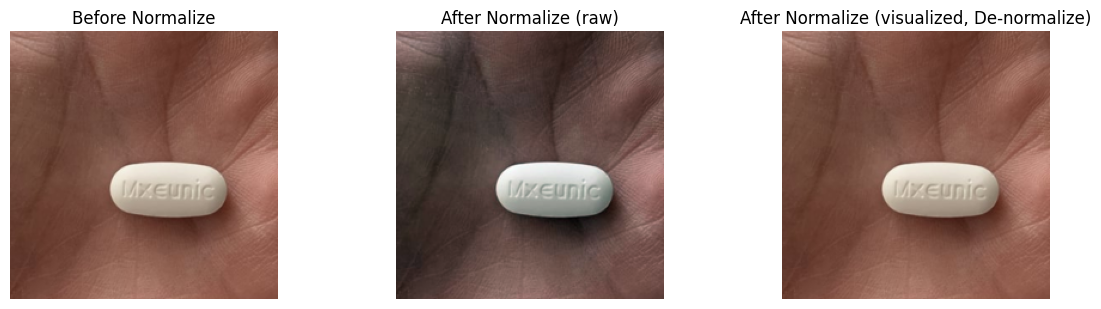

In [32]:
dataset_train = apply_normalization_with_example(dataset_train, mean_train, std_train, example_index=0, show_example=True)

In [33]:
dataset_valid = apply_normalization_with_example(dataset_valid, mean_valid, std_valid, example_index=29, show_example=False)

############################################  Transform (after normalization)
 1. Resize
 2. CenterCrop
 3. ToTensor
 4. Normalize


In [34]:
dataset_test = apply_normalization_with_example(dataset_test, mean_test, std_test, example_index=14, show_example=False)

############################################  Transform (after normalization)
 1. Resize
 2. CenterCrop
 3. ToTensor
 4. Normalize


In [35]:
############################################  Preview first 2 items from dataset_train
for i in range(2):
    sample = dataset_train[i]
    print(f"\n===== Sample {i} =====")
    for k, v in sample.items():
        if k == "image":
            print(f"{k}: tensor {tuple(v.shape)} (C,H,W)")
        else:
            print(f"{k}: {v}")


===== Sample 0 =====
image: tensor (3, 224, 224) (C,H,W)
id: awxhir
y2: 1
y3: 0
y6: 0
width: 320
height: 426
img_path: /Users/abdullah/Desktop/Courses/Pattern/project_dataset/fakeddit_data/multimodal_only_samples/train_images/awxhir.jpg

===== Sample 1 =====
image: tensor (3, 224, 224) (C,H,W)
id: 6f2cy5
y2: 1
y3: 0
y6: 0
width: 320
height: 179
img_path: /Users/abdullah/Desktop/Courses/Pattern/project_dataset/fakeddit_data/multimodal_only_samples/train_images/6f2cy5.jpg


## Label Distribution Summary

In [36]:
def summarize_label_distribution(train_ds, valid_ds, test_ds, label_key="y2"):
    def dist(ds):
        counts = Counter(int(ds[i][label_key]) for i in range(len(ds)))
        total = len(ds)
        rows = []
        for lbl, cnt in sorted(counts.items()):
            rows.append((lbl, cnt, f"{cnt/total:.2%}"))
        return total, rows

    print("############################################ Label Distribution Summary")
    
    for name, ds in [("Train", train_ds), ("Valid", valid_ds), ("Test", test_ds)]:
        total, rows = dist(ds)
        print(f"\n{name} set: {total} samples")
        for lbl, cnt, pct in rows:
            print(f"  class {lbl}: {cnt} ({pct})")

In [37]:
# For 2-way task
summarize_label_distribution(dataset_train, dataset_valid, dataset_test, label_key="y2")

# For 3-way task
summarize_label_distribution(dataset_train, dataset_valid, dataset_test, label_key="y3")

# For 6-way task
summarize_label_distribution(dataset_train, dataset_valid, dataset_test, label_key="y6")

############################################ Label Distribution Summary

Train set: 19815 samples
  class 0: 8835 (44.59%)
  class 1: 10980 (55.41%)

Valid set: 1993 samples
  class 0: 891 (44.71%)
  class 1: 1102 (55.29%)

Test set: 1988 samples
  class 0: 860 (43.26%)
  class 1: 1128 (56.74%)
############################################ Label Distribution Summary

Train set: 19815 samples
  class 0: 10980 (55.41%)
  class 1: 736 (3.71%)
  class 2: 8099 (40.87%)

Valid set: 1993 samples
  class 0: 1102 (55.29%)
  class 1: 62 (3.11%)
  class 2: 829 (41.60%)

Test set: 1988 samples
  class 0: 1128 (56.74%)
  class 1: 78 (3.92%)
  class 2: 782 (39.34%)
############################################ Label Distribution Summary

Train set: 19815 samples
  class 0: 10980 (55.41%)
  class 1: 1700 (8.58%)
  class 2: 5259 (26.54%)
  class 3: 564 (2.85%)
  class 4: 158 (0.80%)
  class 5: 1154 (5.82%)

Valid set: 1993 samples
  class 0: 1102 (55.29%)
  class 1: 180 (9.03%)
  class 2: 534 (26.79%)
 

## Model Training

In [38]:
###################################
#################### Model definition
###################################
class TinyImgNumClassifier(nn.Module):
    def __init__(self, num_classes=1, num_numeric=2):
        super().__init__()
        self.img = nn.Sequential(
            nn.Conv2d(3, 32, 5, 2, 2), nn.ReLU(True),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(True),
            nn.Conv2d(64,128, 3, 2, 1), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.num = nn.Sequential(
            nn.Linear(num_numeric, 32), nn.ReLU(True),
            nn.Linear(32, 16), nn.ReLU(True),
        )
        self.head = nn.Sequential(
            nn.Linear(128 + 16, 64), nn.ReLU(True),
            nn.Linear(64, num_classes),
        )
    def forward(self, x_img, x_num):
        z_img = self.img(x_img).flatten(1)
        z_num = self.num(x_num)
        out = self.head(torch.cat([z_img, z_num], dim=1))  # [B, C] where C = num_classes
        return out.squeeze(1) if out.shape[1] == 1 else out

### Dataset helpers

In [39]:
############################################### Pick a random subset of a dataset, up to max_items
def pick_subset_limit(ds, max_items, seed=42):
    if (max_items is None) or (max_items >= len(ds)):
        return ds
    idx = list(range(len(ds))); random.Random(seed).shuffle(idx)
    return Subset(ds, idx[:max_items])

############################################### Compute mean/std for numeric features like width/height
def compute_numeric_stats(ds, numeric_keys):
    cols = {k: [] for k in numeric_keys}
    for i in range(len(ds)):
        sample = ds[i]
        for k in numeric_keys: cols[k].append(float(sample[k]))
    mean = torch.tensor([sum(cols[k])/len(cols[k]) for k in numeric_keys], dtype=torch.float32)
    std  = []
    for k in numeric_keys:
        s = torch.tensor(cols[k]).float().std(unbiased=False).item()
        std.append(s if s > 0 else 1.0)
    std = torch.tensor(std, dtype=torch.float32)
    return mean, std

############################################### Collate function to merge image + numeric features + label into a batch
def collate_batch_with_numeric(batch, num_mean, num_std, num_keys, label_key):
    imgs = torch.stack([b["image"] for b in batch], dim=0)
    nums = torch.tensor([[float(b[k]) for k in num_keys] for b in batch], dtype=torch.float32)
    nums = (nums - num_mean) / num_std
    if label_key == "y2":
        y = torch.tensor([int(b["y2"]) for b in batch], dtype=torch.float32)
    else:
        y = torch.tensor([int(b[label_key]) for b in batch], dtype=torch.long)
    return imgs, nums, y

############################################### Create a DataLoader with custom collate for images + numeric features
def make_dataloader(ds, batch_size, num_mean, num_std, num_keys, label_key, shuffle, num_workers):
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, pin_memory=True,
        collate_fn=lambda b: collate_batch_with_numeric(b, num_mean, num_std, num_keys, label_key),
    )

### Helper Functions for Training

In [40]:
###################################
#################### Training helpers
###################################
def get_loss_function(label_key):
    return nn.BCEWithLogitsLoss() if label_key == "y2" else nn.CrossEntropyLoss()

def compute_accuracy(logits, targets, label_key):
    if label_key == "y2":
        preds = (torch.sigmoid(logits) >= 0.5).long()
    else:
        preds = torch.argmax(logits, dim=1)
    return (preds == targets.long()).float().mean().item()

def run_one_epoch(model, loader, loss_fn, label_key, optimizer=None, device="cpu", desc="train"):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss = total_acc = n = 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for x_img, x_num, y in pbar:
        x_img, x_num, y = x_img.to(device), x_num.to(device), y.to(device)
        if train_mode: optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(train_mode):
            logits = model(x_img, x_num)
            loss = loss_fn(logits, y)
            if train_mode:
                loss.backward(); optimizer.step()
        acc = compute_accuracy(logits.detach(), y, label_key)
        total_loss += loss.item(); total_acc += acc; n += 1
        pbar.set_postfix(loss=f"{loss.item():.3f}", acc=f"{acc:.3f}")
    return total_loss/max(1,n), total_acc/max(1,n)

### Calculating and Plotting Results

In [41]:
###################################
#################### Simple evaluation (metrics + optional confusion plot)
###################################
def evaluate_simple(model, loader, label_key, device, show_plot=True, split_name="Test"):
    model.eval()
    y_true, y_pred, y_score = [], [], []

    with torch.no_grad():
        for x_img, x_num, y in loader:
            x_img, x_num = x_img.to(device), x_num.to(device)
            logits = model(x_img, x_num)                        # [B] for y2, [B,C] for y3/y6

            if label_key == "y2":
                p1   = torch.sigmoid(logits).cpu().numpy()      # prob of class 1
                pred = (p1 >= 0.5).astype(np.int64)
                y_score.append(p1)
            else:
                probs = torch.softmax(logits, dim=1).cpu().numpy()
                pred  = probs.argmax(1)
                y_score.append(probs)

            y_pred.append(pred)
            y_true.append(y.cpu().numpy().astype(np.int64))

    y_true  = np.concatenate(y_true)
    y_pred  = np.concatenate(y_pred)
    y_score = np.concatenate(y_score)

    # ################### metrics
    acc = accuracy_score(y_true, y_pred)
    prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    print(f"\n############################################ {split_name} metrics")
    print(f"accuracy   : {acc:.4f}")
    print(f"precisionM : {prec_m:.4f}")
    print(f"recallM    : {rec_m:.4f}")
    print(f"f1_macro   : {f1_m:.4f}")

    if label_key == "y2":
        roc = roc_auc_score(y_true, y_score)
        pr  = average_precision_score(y_true, y_score)
        print(f"roc_auc    : {roc:.4f}")
        print(f"pr_auc     : {pr:.4f}")

    # ################### confusion matrix (single, small)
    if show_plot:
        disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, normalize="true"))
        fig, ax = plt.subplots(figsize=(4.2, 3.6))
        disp.plot(values_format=".2f", cmap="Blues", ax=ax, colorbar=False)
        ax.set_title(f"{split_name} (normalized confusion)")
        plt.tight_layout()
        plt.show()

    return {"accuracy": acc, "f1_macro": f1_m, "precision_macro": prec_m, "recall_macro": rec_m}

### Main Model Train / Test Function

In [42]:
###################################
#################### Main pipeline (updated: calls evaluate_simple on TEST)
###################################
def train_eval_pipeline(
    dataset_train, dataset_valid, dataset_test,
    label_key="y2", feature_names=("width","height"),
    max_train=10000, max_valid=1000, max_test=1000,
    batch_size=32, epochs=5, lr=1e-3, num_workers=0,
):
    # ---------- spec ----------
    print("############################################ Spec")
    print("features:", ["image", *feature_names])
    print("label   :", label_key)
    num_classes = 1 if label_key == "y2" else (3 if label_key == "y3" else 6)

    # ---------- subsets ----------
    train_ds = pick_subset_limit(dataset_train, max_train)
    valid_ds = pick_subset_limit(dataset_valid, max_valid)
    test_ds  = pick_subset_limit(dataset_test,  max_test)

    # ---------- scaler ----------
    num_mean, num_std = compute_numeric_stats(train_ds, feature_names)
    print("############################################ Numeric stats (TRAIN)")
    print("mean =", num_mean.tolist(), " std =", num_std.tolist())

    # ---------- loaders ----------
    train_loader = make_dataloader(train_ds, batch_size, num_mean, num_std, feature_names, label_key, True,  num_workers)
    valid_loader = make_dataloader(valid_ds, batch_size, num_mean, num_std, feature_names, label_key, False, num_workers)
    test_loader  = make_dataloader(test_ds,  batch_size, num_mean, num_std, feature_names, label_key, False, num_workers)

    xb, xn, yb = next(iter(train_loader))
    print("############################################ Batch shapes")
    print("images:", tuple(xb.shape), " numeric:", tuple(xn.shape), " labels:", tuple(yb.shape))

    # ---------- model ----------
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = TinyImgNumClassifier(num_classes=num_classes, num_numeric=len(feature_names)).to(device)
    loss_fn = get_loss_function(label_key)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    # ---------- training ----------
    print("############################################ Training")
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = run_one_epoch(model, train_loader, loss_fn, label_key, optimizer=opt,  device=device, desc=f"train {ep}/{epochs}")
        va_loss, va_acc = run_one_epoch(model, valid_loader, loss_fn, label_key, optimizer=None, device=device, desc=f"valid {ep}/{epochs}")
        print(f"Epoch {ep:02d} | train_loss={tr_loss:.4f} acc={tr_acc:.4f} | val_loss={va_loss:.4f} acc={va_acc:.4f}")

    # ---------- test (with extra metrics + simple plot) ----------
    te_loss, te_acc = run_one_epoch(model, test_loader, loss_fn, label_key, optimizer=None, device=device, desc="test")
    print("############################################ TEST")
    print(f"test_loss={te_loss:.4f}  test_acc={te_acc:.4f}")

    test_metrics = evaluate_simple(model, test_loader, label_key, device, show_plot=True, split_name="Test")

    return model, {"mean": num_mean, "std": num_std}, (te_loss, te_acc), test_metrics

### 2_way_label

############################################ Spec
features: ['image', 'width', 'height']
label   : y2
############################################ Numeric stats (TRAIN)
mean = [322.3992004394531, 309.1983947753906]  std = [82.77558898925781, 145.0757293701172]
############################################ Batch shapes
images: (32, 3, 224, 224)  numeric: (32, 2)  labels: (32,)
############################################ Training


Epoch 01 | train_loss=0.6748 acc=0.5821 | val_loss=0.6668 acc=0.6289


Epoch 02 | train_loss=0.6537 acc=0.6228 | val_loss=0.6482 acc=0.6445


Epoch 03 | train_loss=0.6495 acc=0.6276 | val_loss=0.6520 acc=0.6348


Epoch 04 | train_loss=0.6458 acc=0.6343 | val_loss=0.6391 acc=0.6445


Epoch 05 | train_loss=0.6445 acc=0.6347 | val_loss=0.6388 acc=0.6455


############################################ TEST
test_loss=0.6281  test_acc=0.6611

############################################ Test metrics
accuracy   : 0.6560
precisionM : 0.6678
recallM    : 0.6308
f1_macro   : 0.6230
roc_auc    : 0.6523
pr_auc     : 0.6550


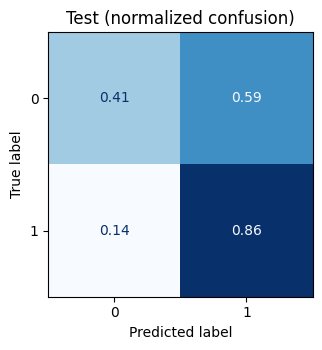

(TinyImgNumClassifier(
   (img): Sequential(
     (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
     (1): ReLU(inplace=True)
     (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
     (3): ReLU(inplace=True)
     (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
     (5): ReLU(inplace=True)
     (6): AdaptiveAvgPool2d(output_size=1)
   )
   (num): Sequential(
     (0): Linear(in_features=2, out_features=32, bias=True)
     (1): ReLU(inplace=True)
     (2): Linear(in_features=32, out_features=16, bias=True)
     (3): ReLU(inplace=True)
   )
   (head): Sequential(
     (0): Linear(in_features=144, out_features=64, bias=True)
     (1): ReLU(inplace=True)
     (2): Linear(in_features=64, out_features=1, bias=True)
   )
 ),
 {'mean': tensor([322.3992, 309.1984]), 'std': tensor([ 82.7756, 145.0757])},
 (0.6281240414828062, 0.6611328125),
 {'accuracy': 0.656,
  'f1_macro': 0.6229657687991021,
  'precision_macro': 0.6677754677

In [43]:
train_eval_pipeline(dataset_train, dataset_valid, dataset_test, label_key="y2")

### 3_way_label

############################################ Spec
features: ['image', 'width', 'height']
label   : y3


/Users/abdullah/.pyenv/versions/3.8.18/lib/python3.8/site-packages/PIL/Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


############################################ Numeric stats (TRAIN)
mean = [322.3992004394531, 309.1983947753906]  std = [82.77558898925781, 145.0757293701172]
############################################ Batch shapes
images: (32, 3, 224, 224)  numeric: (32, 2)  labels: (32,)
############################################ Training


Epoch 01 | train_loss=0.8173 acc=0.5435 | val_loss=0.7810 acc=0.5361


Epoch 02 | train_loss=0.7740 acc=0.6028 | val_loss=0.7458 acc=0.6338


Epoch 03 | train_loss=0.7566 acc=0.6182 | val_loss=0.7348 acc=0.6309


Epoch 04 | train_loss=0.7390 acc=0.6239 | val_loss=0.7218 acc=0.6377


Epoch 05 | train_loss=0.7332 acc=0.6267 | val_loss=0.7167 acc=0.6357


############################################ TEST
test_loss=0.7238  test_acc=0.6426

############################################ Test metrics
accuracy   : 0.6370
precisionM : 0.6711
recallM    : 0.4955
f1_macro   : 0.5111


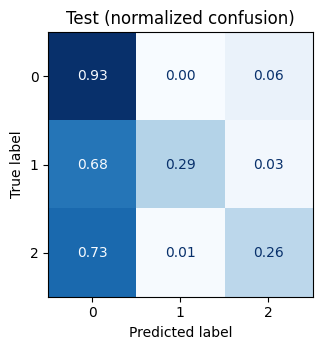

(TinyImgNumClassifier(
   (img): Sequential(
     (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
     (1): ReLU(inplace=True)
     (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
     (3): ReLU(inplace=True)
     (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
     (5): ReLU(inplace=True)
     (6): AdaptiveAvgPool2d(output_size=1)
   )
   (num): Sequential(
     (0): Linear(in_features=2, out_features=32, bias=True)
     (1): ReLU(inplace=True)
     (2): Linear(in_features=32, out_features=16, bias=True)
     (3): ReLU(inplace=True)
   )
   (head): Sequential(
     (0): Linear(in_features=144, out_features=64, bias=True)
     (1): ReLU(inplace=True)
     (2): Linear(in_features=64, out_features=3, bias=True)
   )
 ),
 {'mean': tensor([322.3992, 309.1984]), 'std': tensor([ 82.7756, 145.0757])},
 (0.7238456793129444, 0.642578125),
 {'accuracy': 0.637,
  'f1_macro': 0.5111175480990879,
  'precision_macro': 0.67105590487

In [44]:
train_eval_pipeline(dataset_train, dataset_valid, dataset_test, label_key="y3")

### 6_way_label

############################################ Spec
features: ['image', 'width', 'height']
label   : y6


/Users/abdullah/.pyenv/versions/3.8.18/lib/python3.8/site-packages/PIL/Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


############################################ Numeric stats (TRAIN)
mean = [322.3992004394531, 309.1983947753906]  std = [82.77558898925781, 145.0757293701172]
############################################ Batch shapes
images: (32, 3, 224, 224)  numeric: (32, 2)  labels: (32,)
############################################ Training


Epoch 01 | train_loss=1.2104 acc=0.5555 | val_loss=1.1372 acc=0.5312


Epoch 02 | train_loss=1.0877 acc=0.5661 | val_loss=1.0850 acc=0.5430


Epoch 03 | train_loss=1.0494 acc=0.5815 | val_loss=1.0434 acc=0.5713


Epoch 04 | train_loss=1.0316 acc=0.5838 | val_loss=1.0385 acc=0.5752


Epoch 05 | train_loss=1.0167 acc=0.5887 | val_loss=1.0348 acc=0.5781


############################################ TEST
test_loss=0.9937  test_acc=0.5977

############################################ Test metrics
accuracy   : 0.5940
precisionM : 0.5265
recallM    : 0.4212
f1_macro   : 0.4198


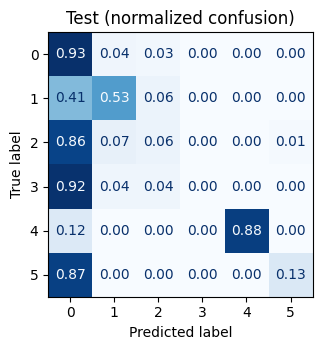

(TinyImgNumClassifier(
   (img): Sequential(
     (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
     (1): ReLU(inplace=True)
     (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
     (3): ReLU(inplace=True)
     (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
     (5): ReLU(inplace=True)
     (6): AdaptiveAvgPool2d(output_size=1)
   )
   (num): Sequential(
     (0): Linear(in_features=2, out_features=32, bias=True)
     (1): ReLU(inplace=True)
     (2): Linear(in_features=32, out_features=16, bias=True)
     (3): ReLU(inplace=True)
   )
   (head): Sequential(
     (0): Linear(in_features=144, out_features=64, bias=True)
     (1): ReLU(inplace=True)
     (2): Linear(in_features=64, out_features=6, bias=True)
   )
 ),
 {'mean': tensor([322.3992, 309.1984]), 'std': tensor([ 82.7756, 145.0757])},
 (0.9937476795166731, 0.59765625),
 {'accuracy': 0.594,
  'f1_macro': 0.41982504006688487,
  'precision_macro': 0.52650785874

In [45]:
train_eval_pipeline(dataset_train, dataset_valid, dataset_test, label_key="y6")